# Analisis Polutan Udara dengan TSFEL dan Klasterisasi Wilayah

Notebook ini mengolah deret waktu **NO2, SO2, dan CO** menjadi fitur numerik, membandingkan interpolasi linear dan polinomial, lalu mendokumentasikan evaluasi PCA/Silhouette serta peta hasil klaster KNIME.

## Peta isi

| Bagian | Isi | Hasil utama |
|---|---|---|
| A | Pemeriksaan data dan interpolasi | Deret waktu siap diolah |
| B | Ekstraksi fitur TSFEL | 68 fitur per polutan; 204 kolom per deret waktu |
| C | Evaluasi PCA dan klaster di KNIME | Perbandingan dimensi dan skor Silhouette |
| D | Pemetaan hasil KNIME | Peta interaktif untuk hasil linier dan polinomial |

> **Penting:** tahap ekstraksi pada bagian B bekerja atas satu deret waktu masukan dan menghasilkan satu baris fitur. Peta KNIME pada bagian D menggunakan tabel hasil klaster dari **37 wilayah** yang diekspor terpisah dari KNIME. Kedua tabel memiliki fungsi dan jumlah baris yang berbeda.

Jalankan sel secara berurutan. Peta yang sudah tersimpan tetap dapat dilihat, tetapi untuk membuat ulang peta diperlukan CSV hasil ekspor KNIME yang dijelaskan sebelum bagian peta.

## A. Pemeriksaan data deret waktu

Berkas sumber yang tersedia di proyek adalah `Polutan_Kertosono.csv`, dengan kolom tanggal serta NO2, SO2, dan CO. Sel berikut juga mencari nama berkas yang digunakan notebook versi sebelumnya, sehingga data dapat diletakkan pada folder proyek atau `mystorage/`.

Pemeriksaan mencakup periode data, keteraturan jarak waktu, nilai kosong, dan contoh baris. Nilai hilang belum diisi pada tahap ini supaya pola data asli terlihat lebih dahulu.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEARCH_ROOTS = list(dict.fromkeys([Path.cwd(), *Path.cwd().parents]))
DATA_NAMES = [
    "Polutan_Kertosono.csv",
    "KualitasUdaraKerek_FinalClean.csv",
    "Non-Linier-Kerek-Clean.csv",
]
DATA_CANDIDATES = [
    root / name
    for root in SEARCH_ROOTS
    for name in DATA_NAMES
]
DATA_CANDIDATES.extend(
    root / "mystorage" / name
    for root in SEARCH_ROOTS
    for name in DATA_NAMES
)
DATA_PATH = next((path for path in DATA_CANDIDATES if path.is_file()), None)
if DATA_PATH is None:
    searched = "\n".join(f"- {path}" for path in DATA_CANDIDATES)
    raise FileNotFoundError(
        "CSV sumber tidak ditemukan. Letakkan Polutan_Kertosono.csv "
        "di folder proyek atau mystorage. Lokasi yang diperiksa:\n"
        f"{searched}"
    )

OUTPUT_DIR = DATA_PATH.parent
raw_data = pd.read_csv(DATA_PATH)
raw_data.columns = raw_data.columns.str.strip()
required_columns = {"date", "NO2", "SO2", "CO"}
missing_columns = required_columns - set(raw_data.columns)
if missing_columns:
    raise ValueError(
        f"Kolom wajib tidak ditemukan di {DATA_PATH.name}: {sorted(missing_columns)}"
    )

raw_data["date"] = pd.to_datetime(
    raw_data["date"], dayfirst=True, errors="coerce"
)
if raw_data["date"].isna().any():
    raise ValueError("Kolom date berisi tanggal kosong atau tidak valid.")
if raw_data["date"].duplicated().any():
    raise ValueError("Kolom date harus unik; periksa baris tanggal yang berulang.")
raw_data = raw_data.sort_values("date").reset_index(drop=True)
for pollutant in ("NO2", "SO2", "CO"):
    raw_data[pollutant] = pd.to_numeric(raw_data[pollutant], errors="coerce")

date_steps = raw_data["date"].diff().dropna().dt.total_seconds()
if date_steps.empty or (date_steps <= 0).any():
    raise ValueError("Tanggal harus berurutan dengan interval waktu positif.")
median_step_seconds = float(date_steps.median())
is_regular = np.allclose(
    date_steps.to_numpy(), median_step_seconds, rtol=0, atol=1
)
if not is_regular:
    raise ValueError(
        "Jarak tanggal tidak seragam. Resampling ke interval tetap diperlukan "
        "sebelum menghitung fitur spektral TSFEL."
    )

SAMPLING_FREQUENCY_HZ = 1 / median_step_seconds
POLYNOMIAL_ORDER = 2
POLLUTANTS = ["NO2", "SO2", "CO"]

print(f"File sumber : {DATA_PATH}")
print(f"Baris data  : {len(raw_data)}")
print(
    f"Periode     : {raw_data['date'].min():%d %b %Y} "
    f"sampai {raw_data['date'].max():%d %b %Y}"
)
print(f"Interval    : {median_step_seconds / 3600:g} jam per pengamatan")
print(f"Frekuensi TSFEL: {SAMPLING_FREQUENCY_HZ:.8g} Hz")

missing_summary = pd.DataFrame(
    {
        "Polutan": POLLUTANTS,
        "Nilai kosong": [int(raw_data[name].isna().sum()) for name in POLLUTANTS],
        "Persentase kosong (%)": [
            100 * raw_data[name].isna().mean() for name in POLLUTANTS
        ],
    }
)
display(missing_summary.round(2))
display(raw_data.head(8))

File sumber : D:\SEMESTER 5\PSD\TUGAS\Polutan_Kertosono.csv
Baris data  : 366
Periode     : 30 Aug 2025 sampai 30 Aug 2026
Interval    : 24 jam per pengamatan
Frekuensi TSFEL: 1.1574074e-05 Hz


,Polutan,Nilai kosong,Persentase kosong (%)
0,NO2,49,13.39
1,SO2,52,14.21
2,CO,46,12.57


,date,CO,NO2,SO2
0,2025-08-30,NaN,NaN,NaN
1,2025-08-31,NaN,0.000020,0.000490
2,2025-09-01,0.027680,0.000042,0.000446
3,2025-09-02,0.022665,0.000024,0.000094
4,2025-09-03,0.020574,0.000031,0.000304
5,2025-09-04,0.034034,NaN,0.000410
6,2025-09-05,0.033311,0.000030,0.000548
7,2025-09-06,0.032180,0.000015,0.000241


### Tampilan awal deret waktu

Setiap garis memperlihatkan pengamatan mentah. Celah pada garis adalah nilai yang kosong, bukan konsentrasi nol. Grafik ini membantu memeriksa cakupan waktu dan pola sebelum nilai kosong/outlier ditangani.

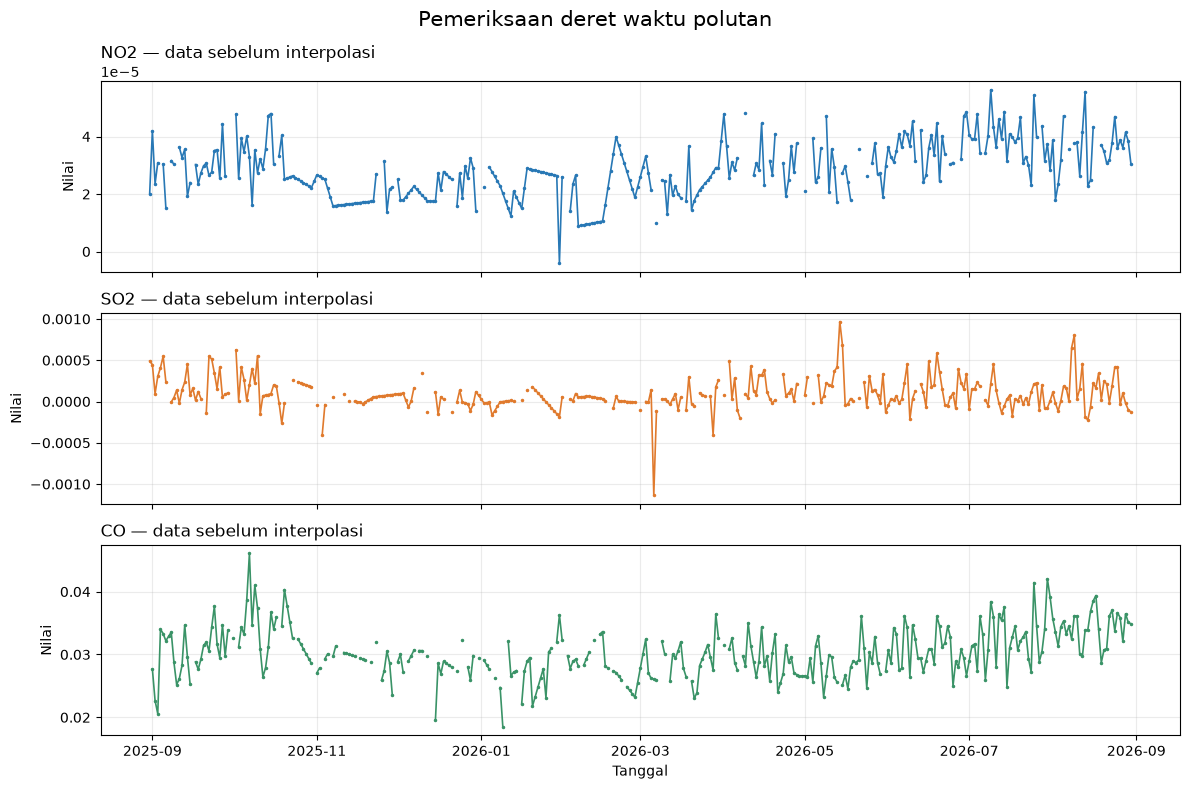

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
palette = {"NO2": "#2878b5", "SO2": "#e07a2d", "CO": "#3a9367"}

for ax, pollutant in zip(axes, POLLUTANTS):
    ax.plot(
        raw_data["date"],
        raw_data[pollutant],
        color=palette[pollutant],
        linewidth=1.2,
        marker=".",
        markersize=3,
    )
    ax.set_title(f"{pollutant} — data sebelum interpolasi", loc="left")
    ax.set_ylabel("Nilai")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Tanggal")
fig.suptitle("Pemeriksaan deret waktu polutan", fontsize=15)
fig.tight_layout()
plt.show()

## B1. Interpolasi linear berbasis waktu

Interpolasi linear mengisi celah dengan garis lurus antara pengamatan valid sebelum dan sesudahnya. Untuk setiap polutan, alur berikut mengubah nilai non-numerik menjadi kosong, menandai nilai di luar batas IQR sebagai kosong, menginterpolasi berdasarkan tanggal, lalu menghitung 68 fitur TSFEL.

Batas outlier menggunakan $Q_1 - 1.5\,IQR$ dan $Q_3 + 1.5\,IQR$, dengan $IQR = Q_3 - Q_1$. Nilai ekstrem yang sebenarnya merupakan episode polusi dapat ikut ditandai; periksa grafik dan konteks sebelum memakai hasil untuk kesimpulan substantif.

Karena pengamatan sumber berjarak satu hari, frekuensi sampling yang diberikan ke TSFEL dihitung dari selang waktu aktual. Fitur spektral bergantung pada frekuensi ini.

In [3]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# Gunakan data tervalidasi dari bagian A.
df = raw_data.copy()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = SAMPLING_FREQUENCY_HZ

# ---------- 2. Daftar PERSIS 68 fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

if len(FEATURE_LIST) != 68:
    raise ValueError(f"Daftar seharusnya berisi 68 fitur, bukan {len(FEATURE_LIST)}.")
print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


# Dictionary untuk menampung seluruh hasil ekstraksi dari semua polutan
combined_row = {}

# ---------- 3. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")
    
    # Buat copy dataframe agar tidak saling menimpa
    df_poly = df[['date', pollutant]].copy()

    # Paksa kolom target jadi numerik
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')
    n_missing_before = df_poly[pollutant].isna().sum()
    print(f"Jumlah NaN/non-numerik pada {pollutant}: {n_missing_before}")

    # Handling outlier dengan IQR
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    # Interpolasi waktu dan cleaning
    df_clean = df_poly.set_index('date').interpolate(method='time').ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 4. Simpan ke DataFrame final (1 baris, 204 kolom) ----------
extracted_features_final = pd.DataFrame([combined_row])

print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = 'TSFEL-fitur-linear.csv'
output_path = OUTPUT_DIR / output_filename
extracted_features_final.to_csv(output_path, index=False)
print(f"File berhasil disimpan sebagai: {output_path}")
print(f"Ukuran tabel hasil: {extracted_features_final.shape[0]} baris x {extracted_features_final.shape[1]} kolom")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 49



--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 52



--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 46



Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: D:\SEMESTER 5\PSD\TUGAS\TSFEL-fitur-linear.csv
Ukuran tabel hasil: 1 baris x 204 kolom


### Membaca hasil ekstraksi

Setiap pemanggilan pada tiga polutan menghasilkan **68 nilai fitur**. Karena fungsi-fungsi TSFEL dapat mengembalikan vektor, kode mengubah hasil tersebut menjadi satu angka representatif agar tabel akhir hanya memiliki satu baris.

Maka, untuk satu deret waktu gabungan, keluaran berisi **1 baris × 204 kolom** (`68 × 3`). Nama kolom memakai awalan polutan, misalnya `NO2_abs_energy`, agar asal setiap fitur tetap jelas. CSV disimpan di folder yang sama dengan data sumber.

## B2. Interpolasi polinomial orde 2

Interpolasi polinomial mengisi celah menggunakan kurva polinomial, sehingga nilai yang diestimasi dapat mengikuti perubahan yang melengkung. Untuk menjaga perbandingan tetap sepadan, bagian ini memakai sumber data, aturan IQR, daftar fitur, dan frekuensi sampling yang sama dengan jalur linear. Perbedaannya hanya pada cara mengisi celah: `method='polynomial'` dengan **orde 2**.

Pemilihan orde memengaruhi nilai hasil interpolasi. Orde yang tinggi dapat menimbulkan osilasi, terutama pada rentang dengan sedikit pengamatan valid.

In [4]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# Gunakan data tervalidasi dari bagian A.
df = raw_data.copy()

# Bersihkan spasi berlebih pada nama kolom CSV
df.columns = df.columns.str.strip()
print("Kolom yang tersedia di DataFrame:", df.columns.tolist())

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = SAMPLING_FREQUENCY_HZ

# ---------- 2. Daftar PERSIS 68 fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

if len(FEATURE_LIST) != 68:
    raise ValueError(f"Daftar seharusnya berisi 68 fitur, bukan {len(FEATURE_LIST)}.")
print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


# Dictionary untuk menampung seluruh hasil ekstraksi dari semua polutan
combined_row = {}

# ---------- 3. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    actual_col = pollutant
    if actual_col not in df.columns:
        match = [c for c in df.columns if c.lower() == pollutant.lower()]
        if match:
            actual_col = match[0]
        else:
            raise KeyError(f"Kolom polutan '{pollutant}' tidak ditemukan di CSV.")

    print(f"\n--- Memproses polutan: {pollutant} ---")
    
    # Buat copy dataframe agar tidak saling menimpa
    df_poly = df[['date', actual_col]].copy()

    # --- PEMBERSIHAN FORMAT ANGKA SESUAI STRruktur FILE ---
    s_col = df_poly[actual_col].astype(str)
    
    if actual_col == 'CO':
        # CO menggunakan titik sebagai pemisah (contoh: 271.170...) -> hapus titiknya
        s_col = s_col.str.replace('.', '', regex=False)
    else:
        # NO2 & SO2 menggunakan koma pada notasi ilmiah (contoh: 3,07E+11) -> ganti koma dengan titik
        s_col = s_col.str.replace(',', '.', regex=False)

    df_poly[actual_col] = pd.to_numeric(s_col, errors='coerce')
    
    n_missing_before = df_poly[actual_col].isna().sum()
    print(f"Jumlah NaN/non-numerik pada {pollutant}: {n_missing_before}")

    # Handling outlier dengan IQR
    Q1 = df_poly[actual_col].quantile(0.25)
    Q3 = df_poly[actual_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[actual_col] < lower_bound) | (df_poly[actual_col] > upper_bound), actual_col] = np.nan

    # Interpolasi polinomial orde 2 dan pengisian nilai di tepi
    df_clean = (
        df_poly.set_index('date')
        .interpolate(method='polynomial', order=POLYNOMIAL_ORDER)
        .ffill()
        .bfill()
    )
    signal_1d = df_clean[actual_col].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 4. Simpan ke DataFrame final (1 baris, 204 kolom) ----------
extracted_features_final = pd.DataFrame([combined_row])

print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = 'TSFEL-fitur-polinomial.csv'
output_path = OUTPUT_DIR / output_filename
extracted_features_final.to_csv(output_path, index=False)
print(f"File berhasil disimpan sebagai: {output_path}")
print(f"Ukuran tabel hasil: {extracted_features_final.shape[0]} baris x {extracted_features_final.shape[1]} kolom")

Kolom yang tersedia di DataFrame: ['date', 'CO', 'NO2', 'SO2']
Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 49



--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 52



--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 46



Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: D:\SEMESTER 5\PSD\TUGAS\TSFEL-fitur-polinomial.csv
Ukuran tabel hasil: 1 baris x 204 kolom


## B3. Membandingkan dua hasil interpolasi

Jalankan kedua sel ekstraksi terlebih dahulu. Tabel berikut membaca keluaran yang baru dibuat dan meringkas jumlah fitur pada masing-masing polutan. Perbandingan nilai antara interpolasi linear dan polinomial sebaiknya dilakukan pada nama fitur yang sama.

In [5]:
linear_path = OUTPUT_DIR / "TSFEL-fitur-linear.csv"
polynomial_path = OUTPUT_DIR / "TSFEL-fitur-polinomial.csv"
available_outputs = [
    path for path in (linear_path, polynomial_path) if path.is_file()
]
if not available_outputs:
    raise FileNotFoundError(
        "Jalankan ekstraksi linear atau polinomial sebelum membandingkan hasil."
    )

output_summary = []
for path in available_outputs:
    result = pd.read_csv(path)
    output_summary.append(
        {
            "Metode": "Polinomial" if "polinomial" in path.stem.lower() else "Linear",
            "Berkas": path.name,
            "Jumlah baris": len(result),
            "Jumlah fitur": len(result.columns),
            "Contoh kolom": ", ".join(result.columns[:3]),
        }
    )
display(pd.DataFrame(output_summary))

,Metode,Berkas,Jumlah baris,Jumlah fitur,Contoh kolom
0,Linear,TSFEL-fitur-linear.csv,1,204,"NO2_abs_energy, NO2_auc, NO2_autocorr"
1,Polinomial,TSFEL-fitur-polinomial.csv,1,204,"NO2_abs_energy, NO2_auc, NO2_autocorr"


# C. Reduksi Dimensi, Evaluasi Silhouette, dan Klasterisasi Wilayah

Bagian ini mendokumentasikan analisis lanjutan yang dilakukan di **KNIME Analytics Platform**. Alur KNIME menggunakan tabel fitur dari **37 wilayah**, membandingkan jalur interpolasi linear dan polinomial, lalu memetakan label klaster.

Peta dan tabel di bagian ini berasal dari ekspor eksperimen KNIME yang telah disimpan dalam notebook. Tabel ekspor 37 wilayah tidak sama dengan tabel satu baris yang dihasilkan sel ekstraksi TSFEL di atas.

## C1. Rangkaian proses di KNIME

Diagram berikut memperlihatkan dua jalur yang dibandingkan. Masing-masing jalur mereduksi data, menguji beberapa jumlah klaster, menghitung Silhouette, lalu memakai hasil klaster untuk peta.

**Jalur linear**

![Workflow KNIME jalur linear](../../img/kl_knime_68.png)

**Jalur polinomial**

![Workflow KNIME jalur polinomial](../../img/kp_knime_68.png)

### Penjelasan tahapan workflow

1. **Membaca tabel fitur:** jalur linear dan polinomial dimulai dari data fitur multi-polutan untuk titik/wilayah pengamatan.
2. **PCA:** jumlah kolom fitur dikurangi sebelum klasterisasi. PCA membentuk komponen baru berupa kombinasi linear fitur yang menjelaskan variasi data.
3. **Uji jumlah klaster:** nilai $k=2,3,4,5,6$ dicoba secara berulang pada jalur dan jumlah komponen yang dipilih.
4. **k-Means:** membagi titik pengamatan berdasarkan kedekatan fitur. Nomor klaster adalah label kategori, bukan urutan tingkat polusi.
5. **Silhouette:** mengukur seberapa dekat suatu titik ke klasternya dibandingkan klaster tetangga.
6. **Peta:** hasil ekspor KNIME digabungkan dengan koordinat wilayah untuk melihat pola sebaran secara geografis.

**Cara menelusuri diagram:** ikuti setiap cabang dari sumber data ke PCA, lalu ke blok looping dan node evaluasi. Pastikan setiap cabang PCA terhubung ke tabel dan Silhouette yang sesuai sebelum membandingkan hasil.

## C2. Memilih jumlah komponen PCA

Dataset klasterisasi dijelaskan memiliki **37 baris wilayah** dan **204 fitur**. Setelah pemusatan data, rank maksimum matriks fitur adalah $\min(p,n-1)$; untuk $p=204$ dan $n=37$, batas teoritisnya **36 komponen non-nol**, bukan 37.

| Skenario pada workflow | Jumlah komponen yang diminta | Makna saat membaca hasil |
|---|---:|---|
| PCA 203 | 203 | Jauh lebih banyak dari rank yang didukung 37 sampel; sebagian komponen dapat bernilai nol atau sangat kecil. |
| PCA 74 | 74 | Lebih ringkas, tetapi tetap melebihi batas rank teoritis data terpusat. |
| PCA 37 | 37 | Mendekati jumlah sampel, namun komponen terakhir dapat redundan/tidak membawa variasi baru. |

PCA hanya berguna jika kolom numerik diproses secara konsisten dan skala fitur sesuai tujuan analisis. **Jangan menyimpulkan bahwa 37 komponen pasti mempertahankan seluruh informasi tanpa redundansi**; periksa nilai eigenvalue/varians yang dijelaskan pada node PCA KNIME.

## C3. Cara membaca Silhouette Coefficient

Untuk titik $i$, skor Silhouette dirumuskan sebagai:

$$
S(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}
$$

`a(i)` adalah rata-rata jarak titik ke anggota klaster yang sama (kohesi), sedangkan `b(i)` adalah rata-rata jarak ke klaster tetangga terdekat (separasi).

Skor mendekati **1** menunjukkan pemisahan yang lebih jelas; skor sekitar **0** menandakan titik berada di batas klaster; nilai negatif berarti titik mungkin lebih dekat ke klaster lain. Gunakan skor sebagai ukuran internal, bukan bukti bahwa klaster mewakili tingkat bahaya polusi.

### C3a. Ringkasan skor — jalur linear

Tabel berikut menyalin skor dari hasil eksperimen KNIME yang dilampirkan. Nilai yang sama persis untuk beberapa dimensi perlu diverifikasi pada output tiap cabang PCA—terutama bila tabel hasil Loop End seharusnya berasal dari model yang berbeda.

| Iterasi Loop | Jumlah Klaster ($k$) | Silhouette **203 Dimensi** (Linier) | Silhouette **74 Dimensi** (Linier) | Silhouette **37 Dimensi** (Linier) | Status Evaluasi |
| :---: | :---: | :---: | :---: | :---: | :--- |
| `Iteration 0` | **$k = 2$** | **`0.822`** | **`0.822`** | **`0.822`** | **Klaster Optimal (Tertinggi)** |
| `Iteration 1` | **$k = 3$** | `0.647` | `0.647` | `0.647` | Segmentasi 3 Zona (Rendah, Sedang, Tinggi) |
| `Iteration 2` | **$k = 4$** | `0.659` | `0.659` | `0.659` | Mulai terjadi pemecahan zona transisi |
| `Iteration 3` | **$k = 5$** | `0.637` | `0.637` | `0.637` | *Over-segmentation* |
| `Iteration 4` | **$k = 6$** | `0.575` | `0.575` | `0.575` | Skor terendah (klaster terlalu kecil) |

**Contoh scatter plot jalur linear untuk $k=3$**

Gambar ini menunjukkan eksperimen tiga klaster (skor overall 0.647 pada tabel), bukan hasil terbaik $k=2$. Label sumbu vertikal adalah kategori klaster; jarak vertikal antarkategori tidak mewakili besaran konsentrasi.

![Scatter plot jalur linear, k=3](../../img/kl_37_s_3.png)

### C3b. Ringkasan skor — jalur polinomial

Skor di bawah berasal dari tabel eksperimen yang dilampirkan. Skor tertinggi yang tercantum adalah $k=2$; untuk jalur ini, skor $k=6$ **bukan** nilai terendah karena masih lebih tinggi daripada skor $k=3$, $k=4$, dan $k=5$.

| Iterasi Loop | Jumlah Klaster ($k$) | Silhouette **203 Dimensi** (Polinomial) | Silhouette **74 Dimensi** (Polinomial) | Silhouette **37 Dimensi** (Polinomial) | Status Evaluasi |
| :---: | :---: | :---: | :---: | :---: | :--- |
| `Iteration 0` | **$k = 2$** | **`0.634`** | **`0.634`** | **`0.634`** | **Klaster Optimal (Tertinggi)** |
| `Iteration 1` | **$k = 3$** | `0.471` | `0.471` | `0.471` | Segmentasi 3 Zona (Rendah, Sedang, Tinggi) |
| `Iteration 2` | **$k = 4$** | `0.466` | `0.466` | `0.466` | Mulai terjadi pemecahan zona transisi |
| `Iteration 3` | **$k = 5$** | `0.486` | `0.486` | `0.486` | *Over-segmentation* |
| `Iteration 4` | **$k = 6$** | `0.554` | `0.554` | `0.554` | Di bawah skor tertinggi pada k=2 |

**Contoh scatter plot jalur polinomial untuk $k=3$**

Gambar ini menunjukkan eksperimen tiga klaster (skor overall 0.471 pada tabel), bukan hasil terbaik $k=2$. Bandingkan pola kelompok dengan jalur linear, tetapi jangan menafsirkan nomor klaster sebagai tingkatan polusi tanpa memeriksa profil fitur tiap klaster.

![Scatter plot jalur polinomial, k=3](../../img/kp_37_s_3.png)

### C3c. Pembahasan hasil secara hati-hati

1. **Jumlah klaster:** pada tabel yang tersedia, $k=2$ memperoleh skor Silhouette tertinggi untuk kedua jalur. Ini mendukung dua kelompok yang relatif terpisah pada konfigurasi tersebut; bukan berarti alamiah hanya memiliki dua tingkat polusi.
2. **Dimensi PCA:** apabila skor untuk 203, 74, dan 37 komponen sama persis, periksa apakah tiap cabang menggunakan keluaran PCA yang benar dan apakah tabel skor diambil dari iterasi/node yang tepat. Kesamaan skor saja tidak membuktikan semua dimensi setara.
3. **Interpolasi:** skor maksimum linear pada tabel lebih tinggi daripada skor maksimum polinomial yang dicantumkan. Hal ini hanya berlaku pada data, prapemrosesan, dan konfigurasi eksperimen tersebut. Interpolasi polinomial tidak otomatis membuat klaster lebih baik.
4. **Label klaster:** k-Means bersifat tidak terawasi. Makna seperti “tinggi”, “rendah”, atau “hotspot” perlu didukung ringkasan konsentrasi NO2, SO2, dan CO per klaster; warna/nomor klaster saja tidak cukup.
5. **Ukuran data:** 37 lokasi adalah sampel yang relatif kecil. Uji kestabilan dengan beberapa seed, cek komposisi setiap klaster, dan gunakan informasi polutan/spasial sebagai validasi tambahan sebelum menarik kesimpulan.

## D. Pemetaan hasil klaster KNIME

Peta di bawah menampilkan dua skenario: fitur linear dan fitur polinomial. Peta bersifat interaktif; gunakan kontrol lapisan di kanan atas untuk memilih kelompok, minimap untuk orientasi, dan hover/klik penanda untuk membaca detail wilayah.

**Berkas yang diperlukan untuk menjalankan ulang sel peta:**

- `mystorage/csv-37-linier.csv`
- `mystorage/csv-37-polinomial.csv`

Setiap berkas harus memuat nama wilayah dan label klaster (kolom `daerah` dan `Cluster`). Berkas ini adalah ekspor **37 wilayah dari KNIME**, bukan CSV fitur satu baris hasil ekstraksi TSFEL. Peta tersimpan di bawah ini berasal dari eksekusi sebelumnya; jika berkas ekspor belum tersedia, sel peta tidak dapat dibuat ulang.

In [ ]:
import folium
from folium.plugins import MiniMap

print(f"Folium {folium.__version__} siap untuk peta interaktif.")

### D1. Hasil klaster pada fitur linear ($k=2$)

Warna membedakan **label klaster**, bukan tingkat konsentrasi. Hover pada marker untuk nama wilayah; klik marker untuk melihat label dan koordinat. Menu layer dapat dipakai untuk menyembunyikan/menampilkan tiap klaster atau mengganti peta dasar.

Koordinat pada marker yang dilengkapi dari nama wilayah merupakan lokasi pendekatan dan dapat digeser sedikit agar marker berdekatan lebih mudah dibedakan. Gunakan peta untuk membaca pola umum, bukan sebagai koordinat pasti stasiun.

In [12]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MiniMap

# =====================================================================
# 1. BACA FILE CSV HASIL EKSPOR DARI NODE k-Means DI KNIME
# =====================================================================
# Pastikan file hasil_cluster_knime.csv memiliki kolom 'daerah' dan 'Cluster'
df = pd.read_csv("mystorage/csv-37-linier.csv")

# Standarisasi penamaan label klaster menjadi 'Cluster 0' dan 'Cluster 1'
df["Cluster_Label"] = df["Cluster"].astype(str).apply(
    lambda x: f"Cluster {x.split('_')[-1]}" if "cluster_" in x.lower() else x
)

# =====================================================================
# 2. KAMUS KOORDINAT KECAMATAN/DAERAH SESUAI SCATTER PLOT KNIME
# =====================================================================
# Mencocokkan kata kunci nama daerah di kolom 'daerah' dengan koordinat aslinya
kamus_koordinat = {
    "baron": (-7.6033, 112.0601),          # Baron, Nganjuk
    "sreseh": (-7.1983, 113.0805),         # Sreseh, Sampang
    "banyu ajuh": (-7.1585, 112.7280),     # Banyu Ajuh, Kamal, Bangkalan
    "banyuajuh": (-7.1620, 112.7310),      # Banyuajuh Kamal, Bangkalan
    "kamal": (-7.1662, 112.7214),          # Kamal, Bangkalan
    "labang": (-7.1294, 112.7936),         # Labang, Bangkalan (Cluster 1)
    "kwanyar": (-7.1604, 112.8569),        # Kwanyar, Bangkalan
    "kecamatan bangkalan": (-7.0325, 112.7450), # Kec. Bangkalan
    "bangkalan": (-7.0455, 112.7351),      # Bangkalan
    "gresik": (-7.1566, 112.6555),         # Gresik Kota, Gresik
    "paciran": (-6.8767, 112.3414),        # Paciran, Lamongan
    "jabon": (-7.5419, 112.7686),          # Jabon, Sidoarjo (Cluster 1)
    "widang": (-6.9850, 112.1647),         # Widang, Tuban
    "kalianget": (-7.0519, 113.9408),      # Kec. Kalianget, Sumenep
    "kota sumenep": (-7.0086, 113.8617),   # Kota Sumenep, Sumenep (Cluster 1)
    "sumenep": (-7.0167, 113.8542),        # Sumenep
    "tikala": (1.4820, 124.8540),          # Tikala, Manado
    "wonokromo": (-7.3006, 112.7383),      # Wonokromo, Surabaya
    "surabaya": (-7.2575, 112.7521),       # Surabaya
    "pilangkenceng": (-7.4931, 111.6664),  # Pilangkenceng, Madiun
    "madiun": (-7.6298, 111.5239),         # Madiun
    "sidoarjo": (-7.4478, 112.7183),       # Sidoarjo
    "tuban": (-6.8976, 112.0463),          # Tuban
    "lamongan": (-7.1193, 112.4167),       # Lamongan
    "sampang": (-7.1872, 113.2394),        # Sampang
    "pamekasan": (-7.1568, 113.4746),      # Pamekasan
    "malang": (-7.9666, 112.6326),         # Malang
    "denpasar": (-8.6705, 115.2126),       # Bali / Denpasar
    "jakarta": (-6.2088, 106.8456),        # Jakarta / Jabar
}

def cari_koordinat(nama_daerah, idx):
    nama_lower = str(nama_daerah).lower()
    for kata_kunci, (lat, lon) in kamus_koordinat.items():
        if kata_kunci in nama_lower:
            # Tambahkan sedikit pergeseran mikro (jitter) agar daerah di kabupaten yang sama
            # tidak saling menumpuk 100% di titik yang sama
            np.random.seed(idx * 42)
            offset_lat = np.random.uniform(-0.025, 0.025)
            offset_lon = np.random.uniform(-0.025, 0.025)
            return lat + offset_lat, lon + offset_lon
    # Default koordinat di Jawa Timur jika nama belum ada di kamus
    return -7.2500 + (idx * 0.02), 112.7500 + (idx * 0.02)

# Jika di tabel sudah ada kolom lat/lon asli, gunakan kolom tersebut; jika belum, cari dari nama 'daerah'
if "latitude" not in df.columns or "longitude" not in df.columns:
    coords = [cari_koordinat(row["daerah"], i) for i, row in df.iterrows()]
    df["latitude"] = [c[0] for c in coords]
    df["longitude"] = [c[1] for c in coords]

# =====================================================================
# 3. MEMBUAT PETA INTERAKTIF FOLIUM (PERSIS SEPERTI DESAIN GAMBAR)
# =====================================================================
def render_peta_knime(df_data, nama_dataset="Linier-37", k_val=2, sil_score=0.822):
    m = folium.Map(location=[-7.2, 113.0], zoom_start=7, tiles=None, control_scale=True)

    # Layer Pilihan Peta Dasar (Kanan Atas)
    folium.TileLayer("OpenStreetMap", name="OpenStreetMap (default)").add_to(m)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
        attr="Esri", name="Esri Street Map"
    ).add_to(m)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri", name="Citra Satelit (Esri)"
    ).add_to(m)

    palet_warna = {
        "Cluster 0": "#e53935",  # Merah (33 wilayah)
        "Cluster 1": "#1e88e5",  # Biru  (4 wilayah)
        "Cluster 2": "#43a047",  # Hijau (jika k=3)
    }

    unique_clusters = sorted(df_data["Cluster_Label"].unique())
    fg_dict = {}
    for c_name in unique_clusters:
        fg = folium.FeatureGroup(name=c_name, show=True)
        fg.add_to(m)
        fg_dict[c_name] = fg

    # Urutkan agar Cluster 1 di-plot paling akhir (berada di lapisan paling atas & tidak tertutup C0!)
    df_sorted = df_data.sort_values(by="Cluster_Label", ascending=True)

    for idx, row in df_sorted.iterrows():
        c_name = row["Cluster_Label"]
        c_num = c_name.split()[-1]
        short_code = f"C{c_num}"
        color = palet_warna.get(c_name, "#e53935")
        z_idx = 1000 if c_name == "Cluster 1" else 100  # Pastikan C1 selalu tampil di depan

        icon_html = f"""
        <div style="
            background-color: {color};
            color: white;
            border-radius: 50%;
            width: 30px;
            height: 30px;
            display: flex;
            align-items: center;
            justify-content: center;
            font-family: Arial, sans-serif;
            font-size: 10px;
            font-weight: bold;
            border: 2px solid white;
            box-shadow: 0 2px 6px rgba(0,0,0,0.45);
        ">{short_code}</div>
        """

        popup_html = f"""
        <div style="font-family: Arial; font-size: 12px; min-width: 160px;">
            <b>{row['daerah']}</b><hr style="margin: 4px 0;">
            <b>Klaster:</b> {c_name} ({short_code})<br>
            <b>Koordinat:</b> {row['latitude']:.4f}, {row['longitude']:.4f}
        </div>
        """

        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            icon=folium.DivIcon(html=icon_html, icon_size=(30, 30), icon_anchor=(15, 15)),
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{row['daerah']} ({short_code})",
            z_index_offset=z_idx
        ).add_to(fg_dict[c_name])

    # Tambahkan MiniMap & LayerControl
    MiniMap(toggle_display=True, position="bottomright").add_to(m)
    folium.LayerControl(collapsed=False, position="topright").add_to(m)

    # Hitung otomatis jumlah wilayah per klaster (Otomatis tertulis 33 wilayah & 4 wilayah!)
    counts = df_data["Cluster_Label"].value_counts()
    item_legenda_html = ""
    for c_name in unique_clusters:
        jml = counts.get(c_name, 0)
        color = palet_warna.get(c_name, "#e53935")
        item_legenda_html += f"""
        <div style="display: flex; align-items: center; margin-bottom: 6px; font-size: 13px; color: #333;">
            <span style="display:inline-block; width: 14px; height: 14px; border-radius: 50%; background-color: {color}; margin-right: 10px;"></span>
            <span>{c_name} &mdash; {jml} wilayah</span>
        </div>
        """

    legend_card_html = f"""
    <div style="
        position: fixed;
        bottom: 45px;
        left: 20px;
        z-index: 9999;
        background-color: white;
        padding: 16px 20px;
        border-radius: 12px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.18);
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        min-width: 240px;
    ">
        <div style="font-size: 15px; font-weight: 700; color: #1a1a1a; margin-bottom: 4px;">
            Segmentasi Cluster
        </div>
        <div style="font-size: 12px; color: #777; margin-bottom: 12px;">
            Dataset: {nama_dataset} | k={k_val} | Sil={sil_score:.3f}
        </div>
        {item_legenda_html}
        <div style="font-size: 11px; color: #999; margin-top: 10px;">
            Klik marker untuk detail
        </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_card_html))
    return m

# Jalankan dan simpan peta
peta_knime = render_peta_knime(df, nama_dataset="PCA-37", k_val=2, sil_score=0.538)
peta_knime.save("peta_segmentasi_33_dan_4_wilayah.html")
peta_knime

### D2. Hasil klaster pada fitur polinomial ($k=2$)

Gunakan cara baca yang sama seperti peta linear. Bandingkan lokasi yang berpindah klaster di antara kedua peta; perpindahan menunjukkan sensitivitas pengelompokan terhadap representasi/interpolasi fitur. Perbedaan warna tidak langsung menunjukkan kenaikan atau penurunan pencemaran.

In [13]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MiniMap

# =====================================================================
# 1. BACA FILE CSV HASIL EKSPOR DARI NODE k-Means DI KNIME
# =====================================================================
# Pastikan file hasil_cluster_knime.csv memiliki kolom 'daerah' dan 'Cluster'
df = pd.read_csv("mystorage/csv-37-polinomial.csv")

# Standarisasi penamaan label klaster menjadi 'Cluster 0' dan 'Cluster 1'
df["Cluster_Label"] = df["Cluster"].astype(str).apply(
    lambda x: f"Cluster {x.split('_')[-1]}" if "cluster_" in x.lower() else x
)

# =====================================================================
# 2. KAMUS KOORDINAT KECAMATAN/DAERAH SESUAI SCATTER PLOT KNIME
# =====================================================================
# Mencocokkan kata kunci nama daerah di kolom 'daerah' dengan koordinat aslinya
kamus_koordinat = {
    "baron": (-7.6033, 112.0601),          # Baron, Nganjuk
    "sreseh": (-7.1983, 113.0805),         # Sreseh, Sampang
    "banyu ajuh": (-7.1585, 112.7280),     # Banyu Ajuh, Kamal, Bangkalan
    "banyuajuh": (-7.1620, 112.7310),      # Banyuajuh Kamal, Bangkalan
    "kamal": (-7.1662, 112.7214),          # Kamal, Bangkalan
    "labang": (-7.1294, 112.7936),         # Labang, Bangkalan (Cluster 1)
    "kwanyar": (-7.1604, 112.8569),        # Kwanyar, Bangkalan
    "kecamatan bangkalan": (-7.0325, 112.7450), # Kec. Bangkalan
    "bangkalan": (-7.0455, 112.7351),      # Bangkalan
    "gresik": (-7.1566, 112.6555),         # Gresik Kota, Gresik
    "paciran": (-6.8767, 112.3414),        # Paciran, Lamongan
    "jabon": (-7.5419, 112.7686),          # Jabon, Sidoarjo (Cluster 1)
    "widang": (-6.9850, 112.1647),         # Widang, Tuban
    "kalianget": (-7.0519, 113.9408),      # Kec. Kalianget, Sumenep
    "kota sumenep": (-7.0086, 113.8617),   # Kota Sumenep, Sumenep (Cluster 1)
    "sumenep": (-7.0167, 113.8542),        # Sumenep
    "tikala": (1.4820, 124.8540),          # Tikala, Manado
    "wonokromo": (-7.3006, 112.7383),      # Wonokromo, Surabaya
    "surabaya": (-7.2575, 112.7521),       # Surabaya
    "pilangkenceng": (-7.4931, 111.6664),  # Pilangkenceng, Madiun
    "madiun": (-7.6298, 111.5239),         # Madiun
    "sidoarjo": (-7.4478, 112.7183),       # Sidoarjo
    "tuban": (-6.8976, 112.0463),          # Tuban
    "lamongan": (-7.1193, 112.4167),       # Lamongan
    "sampang": (-7.1872, 113.2394),        # Sampang
    "pamekasan": (-7.1568, 113.4746),      # Pamekasan
    "malang": (-7.9666, 112.6326),         # Malang
    "denpasar": (-8.6705, 115.2126),       # Bali / Denpasar
    "jakarta": (-6.2088, 106.8456),        # Jakarta / Jabar
}

def cari_koordinat(nama_daerah, idx):
    nama_lower = str(nama_daerah).lower()
    for kata_kunci, (lat, lon) in kamus_koordinat.items():
        if kata_kunci in nama_lower:
            # Tambahkan sedikit pergeseran mikro (jitter) agar daerah di kabupaten yang sama
            # tidak saling menumpuk 100% di titik yang sama
            np.random.seed(idx * 42)
            offset_lat = np.random.uniform(-0.025, 0.025)
            offset_lon = np.random.uniform(-0.025, 0.025)
            return lat + offset_lat, lon + offset_lon
    # Default koordinat di Jawa Timur jika nama belum ada di kamus
    return -7.2500 + (idx * 0.02), 112.7500 + (idx * 0.02)

# Jika di tabel sudah ada kolom lat/lon asli, gunakan kolom tersebut; jika belum, cari dari nama 'daerah'
if "latitude" not in df.columns or "longitude" not in df.columns:
    coords = [cari_koordinat(row["daerah"], i) for i, row in df.iterrows()]
    df["latitude"] = [c[0] for c in coords]
    df["longitude"] = [c[1] for c in coords]

# =====================================================================
# 3. MEMBUAT PETA INTERAKTIF FOLIUM (PERSIS SEPERTI DESAIN GAMBAR)
# =====================================================================
def render_peta_knime(df_data, nama_dataset="Poly-37", k_val=2, sil_score=0.634):
    m = folium.Map(location=[-7.2, 113.0], zoom_start=7, tiles=None, control_scale=True)

    # Layer Pilihan Peta Dasar (Kanan Atas)
    folium.TileLayer("OpenStreetMap", name="OpenStreetMap (default)").add_to(m)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
        attr="Esri", name="Esri Street Map"
    ).add_to(m)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri", name="Citra Satelit (Esri)"
    ).add_to(m)

    palet_warna = {
        "Cluster 0": "#e53935",  # Merah (33 wilayah)
        "Cluster 1": "#1e88e5",  # Biru  (4 wilayah)
        "Cluster 2": "#43a047",  # Hijau (jika k=3)
    }

    unique_clusters = sorted(df_data["Cluster_Label"].unique())
    fg_dict = {}
    for c_name in unique_clusters:
        fg = folium.FeatureGroup(name=c_name, show=True)
        fg.add_to(m)
        fg_dict[c_name] = fg

    # Urutkan agar Cluster 1 di-plot paling akhir (berada di lapisan paling atas & tidak tertutup C0!)
    df_sorted = df_data.sort_values(by="Cluster_Label", ascending=True)

    for idx, row in df_sorted.iterrows():
        c_name = row["Cluster_Label"]
        c_num = c_name.split()[-1]
        short_code = f"C{c_num}"
        color = palet_warna.get(c_name, "#e53935")
        z_idx = 1000 if c_name == "Cluster 1" else 100  # Pastikan C1 selalu tampil di depan

        icon_html = f"""
        <div style="
            background-color: {color};
            color: white;
            border-radius: 50%;
            width: 30px;
            height: 30px;
            display: flex;
            align-items: center;
            justify-content: center;
            font-family: Arial, sans-serif;
            font-size: 10px;
            font-weight: bold;
            border: 2px solid white;
            box-shadow: 0 2px 6px rgba(0,0,0,0.45);
        ">{short_code}</div>
        """

        popup_html = f"""
        <div style="font-family: Arial; font-size: 12px; min-width: 160px;">
            <b>{row['daerah']}</b><hr style="margin: 4px 0;">
            <b>Klaster:</b> {c_name} ({short_code})<br>
            <b>Koordinat:</b> {row['latitude']:.4f}, {row['longitude']:.4f}
        </div>
        """

        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            icon=folium.DivIcon(html=icon_html, icon_size=(30, 30), icon_anchor=(15, 15)),
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=f"{row['daerah']} ({short_code})",
            z_index_offset=z_idx
        ).add_to(fg_dict[c_name])

    # Tambahkan MiniMap & LayerControl
    MiniMap(toggle_display=True, position="bottomright").add_to(m)
    folium.LayerControl(collapsed=False, position="topright").add_to(m)

    # Hitung otomatis jumlah wilayah per klaster (Otomatis tertulis 33 wilayah & 4 wilayah!)
    counts = df_data["Cluster_Label"].value_counts()
    item_legenda_html = ""
    for c_name in unique_clusters:
        jml = counts.get(c_name, 0)
        color = palet_warna.get(c_name, "#e53935")
        item_legenda_html += f"""
        <div style="display: flex; align-items: center; margin-bottom: 6px; font-size: 13px; color: #333;">
            <span style="display:inline-block; width: 14px; height: 14px; border-radius: 50%; background-color: {color}; margin-right: 10px;"></span>
            <span>{c_name} &mdash; {jml} wilayah</span>
        </div>
        """

    legend_card_html = f"""
    <div style="
        position: fixed;
        bottom: 45px;
        left: 20px;
        z-index: 9999;
        background-color: white;
        padding: 16px 20px;
        border-radius: 12px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.18);
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        min-width: 240px;
    ">
        <div style="font-size: 15px; font-weight: 700; color: #1a1a1a; margin-bottom: 4px;">
            Segmentasi Cluster
        </div>
        <div style="font-size: 12px; color: #777; margin-bottom: 12px;">
            Dataset: {nama_dataset} | k={k_val} | Sil={sil_score:.3f}
        </div>
        {item_legenda_html}
        <div style="font-size: 11px; color: #999; margin-top: 10px;">
            Klik marker untuk detail
        </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_card_html))
    return m

# Jalankan dan simpan peta
peta_knime = render_peta_knime(df, nama_dataset="PCA-37", k_val=2, sil_score=0.538)
peta_knime.save("peta_segmentasi_33_dan_4_wilayah.html")
peta_knime

## Ringkasan penggunaan

- Mulai dari CSV sumber yang berisi tanggal, NO2, SO2, dan CO; notebook memeriksa interval waktu serta nilai kosong.
- Jalur linear dan polinomial orde 2 menggunakan data dan aturan pembersihan yang sama agar perbandingan lebih adil.
- Setiap jalur menghasilkan **204 fitur (68 untuk masing-masing dari tiga polutan)** untuk satu deret waktu.
- Tabel dan peta klaster 37 wilayah berasal dari ekspor KNIME yang berbeda. Skor Silhouette menilai pemisahan internal, bukan tingkat bahaya polusi.
- Interpretasi PCA, skor, koordinat, dan kelas klaster harus disertai pemeriksaan sumber data serta validasi substantif.